🔹 Dataset Shape: (84187, 25)

🔹 Missing Values:
  Source Port         0
 Destination Port    0
 Protocol            0
 Flow Duration       0
 Flow Bytes/s        0
 Flow Packets/s      0
 Flow IAT Mean       0
 Flow IAT Std        0
 Flow IAT Max        0
 Flow IAT Min        0
Fwd IAT Mean         0
 Fwd IAT Std         0
 Fwd IAT Max         0
 Fwd IAT Min         0
Bwd IAT Mean         0
 Bwd IAT Std         0
 Bwd IAT Max         0
 Bwd IAT Min         0
Active Mean          0
 Active Max          0
 Active Min          0
Idle Mean            0
 Idle Max            0
 Idle Min            0
label                0
dtype: int64


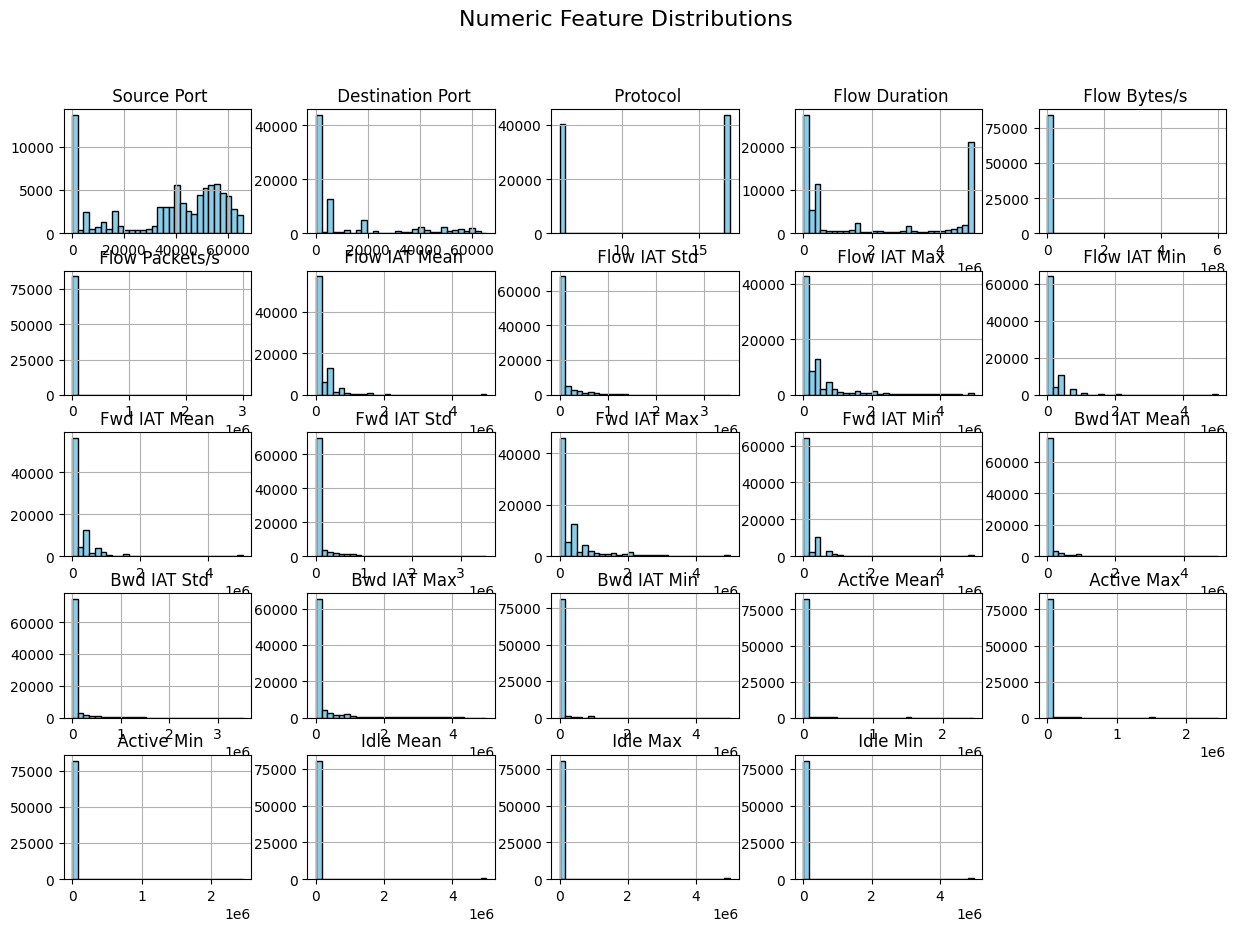

/tmp/ipython-input-3249369364.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="viridis")


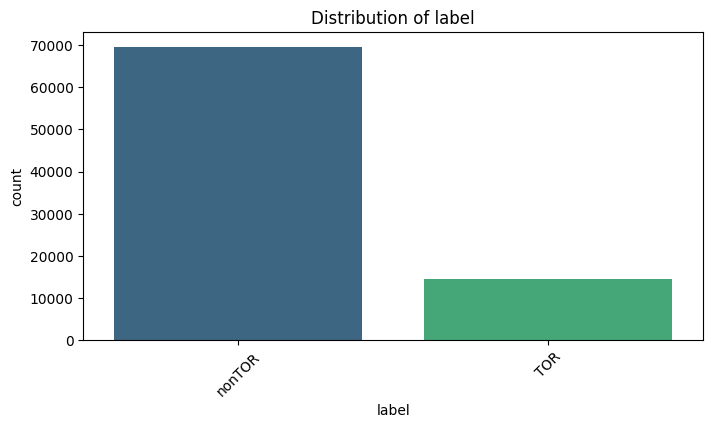

/tmp/ipython-input-3249369364.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="coolwarm")


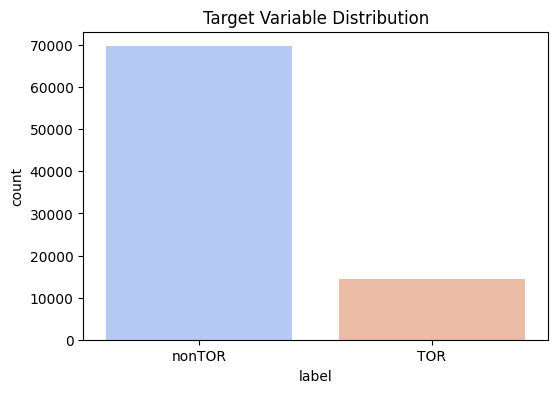


🔹 Summary Statistics (Numeric Columns):
                     count          mean           std     min            25%  \
 Source Port       84187.0  3.655023e+04  2.151424e+04    21.0   15685.000000   
 Destination Port  84187.0  1.316018e+04  1.954844e+04    21.0     137.000000   
 Protocol          84187.0  1.170925e+01  5.496051e+00     6.0       6.000000   
 Flow Duration     84187.0  1.976607e+06  2.143445e+06     1.0  111129.000000   
 Flow Bytes/s      84187.0  2.693915e+05  5.147994e+06     0.0     106.813746   
 Flow Packets/s    84187.0  2.767573e+03  4.374423e+04     0.4       4.874708   
 Flow IAT Mean     84187.0  2.346052e+05  5.300590e+05     0.5    9874.520751   
 Flow IAT Std      84187.0  1.060376e+05  2.847779e+05     0.0       0.000000   
 Flow IAT Max      84187.0  5.085978e+05  8.607961e+05     1.0   35436.500000   
 Flow IAT Min      84187.0  1.692820e+05  5.012896e+05 -2255.0      19.000000   
Fwd IAT Mean       84187.0  2.543009e+05  5.782451e+05     0.0      

In [ ]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose your dataset is a DataFrame called df
df = pd.read_csv("/content/Scenario-A-merged_5s_tor_non_tor.csv")

# 🔹 1️⃣ Basic Info
print("🔹 Dataset Shape:", df.shape)
print("\n🔹 Missing Values:\n", df.isnull().sum())

# 🔹 2️⃣ Numeric Feature Distribution
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Numeric Feature Distributions", fontsize=16)
plt.show()

# 🔹 3️⃣ Categorical Feature Distribution
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette="viridis")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# 🔹 4️⃣ Target Variable Distribution
target_col = 'label'  # replace with your actual target column name
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="coolwarm")
plt.title("Target Variable Distribution")
plt.show()

# 🔹 5️⃣ Summary Statistics
print("\n🔹 Summary Statistics (Numeric Columns):")
print(df.describe().T)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example: df = pd.read_csv("your_data.csv")

# 🔹 Detect numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 🔹 Check skewness
print("🔹 Skewness before log transformation:")
print(df[numeric_cols].skew().sort_values(ascending=False))

🔹 Skewness before log transformation:
 Flow Bytes/s        76.568820
 Flow Packets/s      43.517569
 Bwd IAT Min         11.331792
 Active Min           9.522098
 Active Max           9.522098
Active Mean           9.522098
Bwd IAT Mean          7.313509
 Flow IAT Min         7.229966
 Fwd IAT Min          6.483842
 Flow IAT Mean        6.106636
 Bwd IAT Std          6.077412
Fwd IAT Mean          5.317830
 Flow IAT Std         5.051743
 Idle Max             4.851174
 Idle Min             4.851174
Idle Mean             4.851174
 Fwd IAT Std          4.842186
 Bwd IAT Max          3.551212
 Flow IAT Max         2.901894
 Fwd IAT Max          2.837828
 Destination Port     1.338051
 Flow Duration        0.487282
 Protocol            -0.076149
 Source Port         -0.623801
dtype: float64


In [ ]:

from sklearn.preprocessing import PowerTransformer
import pandas as pd

pt = PowerTransformer(method='yeo-johnson')
df_yeojohnson = pd.DataFrame(pt.fit_transform(df[numeric_cols]), columns=numeric_cols)

print("✅ Yeo-Johnson transform applied successfully.")


✅ Yeo-Johnson transform applied successfully.


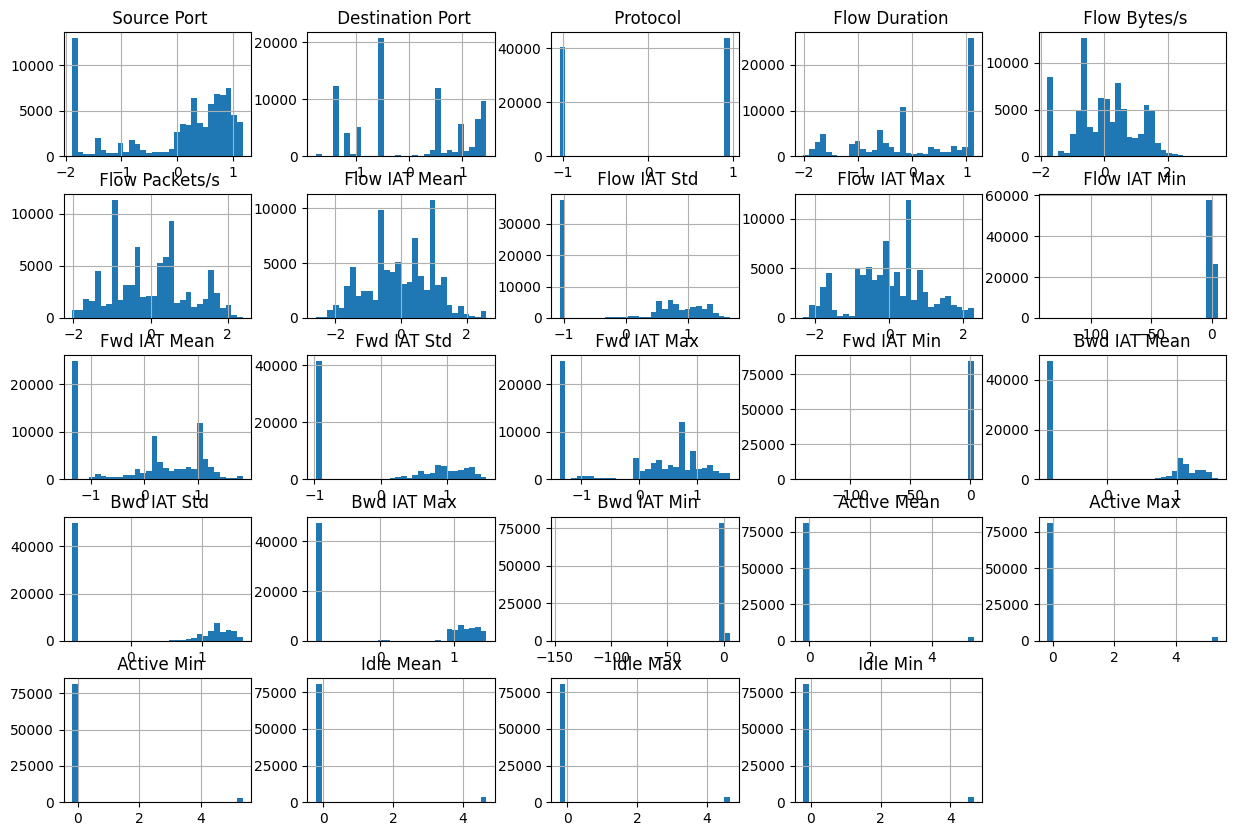

 Active Min           5.185560
 Active Max           5.185560
Active Mean           5.185560
Idle Mean             4.455235
 Idle Max             4.455235
 Idle Min             4.455235
 Bwd IAT Std          0.439312
Bwd IAT Mean          0.331274
 Bwd IAT Max          0.317489
 Fwd IAT Std          0.151500
 Flow Packets/s       0.142856
 Destination Port     0.019167
 Flow IAT Std         0.014132
 Flow Bytes/s        -0.014619
 Flow IAT Mean       -0.075921
 Protocol            -0.076149
 Flow IAT Max        -0.097140
Fwd IAT Mean         -0.255258
 Flow Duration       -0.298615
 Fwd IAT Max         -0.367991
 Source Port         -0.855608
 Flow IAT Min       -29.889497
 Fwd IAT Min        -36.307004
 Bwd IAT Min        -60.041758
dtype: float64


In [ ]:

df_yeojohnson.hist(bins=30, figsize=(15,10))
plt.show()

print(df_yeojohnson.skew().sort_values(ascending=False))

In [ ]:

new = pd.concat([df_yeojohnson, df['label']], axis=1)

In [ ]:
new

,Source Port,Destination Port,Protocol,Flow Duration,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,...,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,label
0,0.770650,-1.209804,-1.038798,-1.694301,-1.813126,1.633367,-1.552348,-1.062802,-1.743449,-0.523026,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
1,0.770650,-1.209804,-1.038798,-1.741891,-1.813126,1.731015,-1.677094,-1.062802,-1.825315,-0.536691,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
2,0.770650,-1.209804,-1.038798,-1.619269,-1.813126,1.482176,-1.366981,-1.062802,-1.616741,-0.497557,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
3,0.770650,-1.209804,-1.038798,-1.597784,-1.813126,1.439431,-1.316112,-1.062802,-1.580937,-0.489356,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
4,0.770650,-1.209804,-1.038798,-1.724538,-1.813126,1.695234,-1.630889,-1.062802,-1.795316,-0.531927,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84182,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,-0.580658,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
84183,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,-0.580658,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
84184,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,-0.580658,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
84185,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,-0.580658,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR


#smote

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
import torch.optim as optim


df = pd.read_csv("/content/new_good_distributed_tor_non-tor_seneriyo_A_data.csv")

X = df.drop("label", axis=1).values
y = df["label"].values

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier()
model.fit(X_res, y_res)

pred = model.predict(X_test)
print("\n=== SMOTE Report ===")
print(classification_report(y_test, pred))


=== SMOTE Report ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2902
           1       1.00      1.00      1.00     13936

    accuracy                           0.99     16838
   macro avg       0.99      0.99      0.99     16838
weighted avg       0.99      0.99      0.99     16838



In [ ]:
import pandas as pd
pd.Series(y_res).value_counts()


,count
0,55744
1,55744


In [ ]:
import pandas as pd

# Assuming X_res and y_res are already defined in your environment
# Convert X_res to a DataFrame. If X_res has column names, use them, otherwise assign default ones.
# For now, let's assume it's a numpy array without original column names for simplicity.
smote_df_combined = pd.DataFrame(X_res)

# Add the resampled target variable as a new column
smote_df_combined['target'] = le.inverse_transform(y_res)

# Display the first few rows of the combined DataFrame
smote_df_combined.head()

# Save the combined DataFrame to a CSV file
smote_df_combined.to_csv('smote_oversampled_tor_nontor_data_combined.csv', index=False)

print("SMOTE oversampled data (features and target) saved to 'smote_oversampled_data_combined.csv'")

SMOTE oversampled data (features and target) saved to 'smote_oversampled_data_combined.csv'


In [ ]:
import pandas as pd

# Verify the saved data by loading it back and displaying its head and value counts for the target
saved_df = pd.read_csv('/content/smote_oversampled_tor_nontor_data_combined.csv')

print("First 5 rows of the saved SMOTE data:")
display(saved_df)

print("\nValue counts of the target variable in the saved SMOTE data:")
display(saved_df['target'].value_counts())


First 5 rows of the saved SMOTE data:


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,0.796780,0.217283,-0.508149,-1.038932,1.133676,0.623801,0.375737,-0.465852,0.735300,-0.250929,...,1.171999,1.074618,-0.201807,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR
1,0.387361,0.380986,-0.508149,-1.038932,-0.787570,0.358172,0.272852,-0.264246,0.890754,-0.333703,...,-0.817316,1.054205,1.481588,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,nonTOR
2,1.554510,0.140325,-0.508149,-1.038932,1.130632,1.533000,1.236541,-1.283964,0.570580,-0.134778,...,1.124129,1.101624,-0.273369,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR
3,-0.503917,0.564753,-0.508149,-1.038932,-0.198871,-0.518044,-0.570682,0.480883,1.197060,0.509786,...,0.504822,0.306386,-0.136002,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,nonTOR
4,0.256657,0.590022,-0.508149,-1.038932,1.127889,0.196880,-0.438758,0.239625,1.101084,0.720066,...,1.366430,1.257059,-0.130396,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111483,1.013110,-1.809225,1.238312,-1.038932,1.130592,0.938415,0.528182,-0.602468,0.821497,0.110831,...,1.261226,1.153456,-0.177501,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR
111484,1.273476,-1.809225,1.294566,-1.038932,1.135574,1.326426,0.977737,-1.024181,0.618582,-0.239440,...,1.166055,1.077562,-0.163341,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR
111485,0.720146,0.461312,-0.508149,-1.038932,1.135085,0.550968,0.255617,-0.359867,0.773051,-0.362759,...,1.190654,1.047190,-0.051728,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR
111486,0.887472,0.814310,-0.508149,-1.038932,1.134203,0.683465,0.375522,-0.465662,0.749802,-0.235476,...,1.198715,1.085723,-0.159068,-0.186934,-0.186934,-0.186934,-0.2149,-0.2149,-0.2149,TOR



Value counts of the target variable in the saved SMOTE data:


,count
target,
TOR,55744
nonTOR,55744


#ML section

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,ConfusionMatrixDisplay,classification_report
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegressionCV,RidgeClassifierCV,LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier, StackingClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
import xgboost
import lightgbm
from catboost import CatBoostClassifier

data = pd.read_csv('/content/drive/MyDrive/IIITM/new_good_distributed_tor_non-tor_seneriyo_A_data.csv')
x  =data.iloc[:,:-1]
y = data.iloc[:,-1]

st = StandardScaler()
x = st.fit_transform(x)

le = LabelEncoder()
y = le.fit_transform(y)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify = y)

In [3]:
m1 = LogisticRegressionCV()
m2 = RidgeClassifierCV()
m3 = DecisionTreeClassifier()
m4 = SVC()
m5 = LinearSVC()
m6 = KNeighborsClassifier()

m1 = m1.fit(x_train,y_train)
m2 = m2.fit(x_train,y_train,)
m3 = m3.fit(x_train,y_train)
m4 = m4.fit(x_train,y_train)
m5 = m5.fit(x_train,y_train)
m6 = m6.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [4]:
y1 = m1.predict(x_test)
y2 = m2.predict(x_test)
y3 = m3.predict(x_test)
y4 = m4.predict(x_test)
y5 = m5.predict(x_test)
y6 = m6.predict(x_test)

accuracy_score1 = accuracy_score(y_test,y1) # LogisticRegressionCV
accuracy_score2 = accuracy_score(y_test,y2) # RidgeClassifierCV"""
accuracy_score3 = accuracy_score(y_test,y3) # DecisionTreeClassifier
accuracy_score4 = accuracy_score(y_test,y4) # SVC
accuracy_score5 = accuracy_score(y_test,y5) # LinearSVC
accuracy_score6 = accuracy_score(y_test,y6) # KNeighborsClassifier


print(f"accuracy_score1 LogisticRegressionCV: {accuracy_score1}")
print(f"accuracy_score2 RidgeClassifierCV: {accuracy_score2}")
print(f"accuracy_score3 DecisionTreeClassifier: {accuracy_score3}")
print(f"accuracy_score4 SVC: {accuracy_score4}")
print(f"accuracy_score5 LinearSVC: {accuracy_score5}")
print(f"accuracy_score6 KNeighborsClassifier: {accuracy_score6}")

accuracy_score1 LogisticRegressionCV: 0.9466682503860316
accuracy_score2 RidgeClassifierCV: 0.929682860197173
accuracy_score3 DecisionTreeClassifier: 0.9896662311438413
accuracy_score4 SVC: 0.9722057251455042
accuracy_score5 LinearSVC: 0.9419764817674308
accuracy_score6 KNeighborsClassifier: 0.9884784416201449


In [5]:
em1 = RandomForestClassifier()
em2 = AdaBoostClassifier()
em3 = GradientBoostingClassifier()
em4 = BaggingClassifier(n_estimators=100,n_jobs=-1)
em5 = ExtraTreesClassifier()
em6 = HistGradientBoostingClassifier()
em9 = xgboost.XGBClassifier()
em10 = lightgbm.LGBMClassifier(n_jobs=-1)
em11 = CatBoostClassifier()
em7= VotingClassifier(estimators=[('m3',m3),('m6',m6),('em1',em1)],voting='hard',n_jobs=-1)
em12= VotingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9)],voting='hard',n_jobs=-1)
em13= VotingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9),('m3',m3),('m6',m6)],voting='hard',n_jobs=-1)
em8 = StackingClassifier(estimators=[('m3',m3),('m6',m6),('em1',em1)],final_estimator=m3,n_jobs=-1)
em14 = StackingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9)],final_estimator=m3,n_jobs=-1)
em15 = StackingClassifier(estimators=[('em1',em1),('em4',em4),('em5',em5),('em6',em6),('em9',em9),('m3',m3),('m6',m6)],final_estimator=m3,n_jobs=-1)

em1 = em1.fit(x_train,y_train)
em2 = em2.fit(x_train,y_train)
em3 = em3.fit(x_train,y_train)
em4 = em4.fit(x_train,y_train)
em5 = em5.fit(x_train,y_train)
em6 = em6.fit(x_train,y_train)
em7 = em7.fit(x_train,y_train)
em8 = em8.fit(x_train,y_train)
em9 = em9.fit(x_train,y_train)
em10 = em10.fit(x_train,y_train)
em11 = em11.fit(x_train,y_train)
em12 = em12.fit(x_train,y_train)
em13 = em13.fit(x_train,y_train)
em14 = em14.fit(x_train,y_train)
em15 = em15.fit(x_train,y_train)

[LightGBM] [Info] Number of positive: 55744, number of negative: 11605
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014790 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6031
[LightGBM] [Info] Number of data points in the train set: 67349, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.827689 -> initscore=1.569334
[LightGBM] [Info] Start training from score 1.569334
Learning rate set to 0.062177
0:	learn: 0.5617216	total: 77.4ms	remaining: 1m 17s
1:	learn: 0.4658698	total: 93.6ms	remaining: 46.7s
2:	learn: 0.3954753	total: 114ms	remaining: 37.9s
3:	learn: 0.3371440	total: 131ms	remaining: 32.7s
4:	learn: 0.2955544	total: 150ms	remaining: 29.9s
5:	learn: 0.2493866	total: 169ms	remaining: 28s
6:	learn: 0.2284778	total: 189ms	remaining: 26.9s
7:	learn: 0.2064872	total: 210ms	remaining: 26.1s
8:	learn: 0.1906096	total: 228ms	remaining: 25.1s
9:	learn: 0.1807146	total: 

In [6]:
ey1 = em1.predict(x_test)
ey2 = em2.predict(x_test)
ey3 = em3.predict(x_test)
ey4 = em4.predict(x_test)
ey5 = em5.predict(x_test)
ey6 = em6.predict(x_test)
ey7 = em7.predict(x_test)
ey8 = em8.predict(x_test)
ey9 = em9.predict(x_test)
ey10 = em10.predict(x_test)
ey11 = em11.predict(x_test)
ey12 = em12.predict(x_test)
ey13 = em13.predict(x_test)
ey14 = em14.predict(x_test)
ey15 = em15.predict(x_test)

e_accuracy_score1 = accuracy_score(y_test,ey1) # RandomForestClassifier
e_accuracy_score2 = accuracy_score(y_test,ey2) # AdaBoostClassifier
e_accuracy_score3 = accuracy_score(y_test,ey3) # GradientBoost
e_accuracy_score4 = accuracy_score(y_test,ey4) # BaggingClassifier
e_accuracy_score5 = accuracy_score(y_test,ey5) # Extra
e_accuracy_score6 = accuracy_score(y_test,ey6) # HistGradient
e_accuracy_score7 = accuracy_score(y_test,ey7)
e_accuracy_score8 = accuracy_score(y_test,ey8)
e_accuracy_score9 = accuracy_score(y_test,ey9) # xgboost
e_accuracy_score10 = accuracy_score(y_test,ey10) # lightgbm
e_accuracy_score11 = accuracy_score(y_test,ey11) # catboost"""
e_accuracy_score12 = accuracy_score(y_test,ey12)
e_accuracy_score13 = accuracy_score(y_test,ey13)
e_accuracy_score14 = accuracy_score(y_test,ey14)
e_accuracy_score15 = accuracy_score(y_test,ey15)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
print(f"e_accuracy_score1 RandomForestClassifier:         {e_accuracy_score1}")
print(f"e_accuracy_score2 AdaBoostClassifier:             {e_accuracy_score2}")
print(f"e_accuracy_score3 GradientBoostingClassifier:     {e_accuracy_score3}")
print(f"e_accuracy_score4 BaggingClassifier:              {e_accuracy_score4}")
print(f"e_accuracy_score5 ExtraTreesClassifier:           {e_accuracy_score5}")
print(f"e_accuracy_score6 HistGradientBoostingClassifier: {e_accuracy_score6}")
print(f"e_accuracy_score7 upper VotingClassifier:         {e_accuracy_score7}")
print(f"e_accuracy_score8 upper StackingClassifier:       {e_accuracy_score8}")
print(f"e_accuracy_score9 xgboost:                        {e_accuracy_score9}")
print(f"e_accuracy_score10 lightgbm:                      {e_accuracy_score10}")
print(f"e_accuracy_score11 CatBoostClassifier:            {e_accuracy_score11}")
print(f"e_accuracy_score12 lower VotingClassifier:        {e_accuracy_score12}")
print(f"e_accuracy_score13 upper+ower VotingClassifier:   {e_accuracy_score13}")
print(f"e_accuracy_score14 lower StackingClassifier:      {e_accuracy_score14}")
print(f"e_accuracy_score15 upper+lower StackingClassifier:{e_accuracy_score15}")

e_accuracy_score1 RandomForestClassifier:         0.9943579997624421
e_accuracy_score2 AdaBoostClassifier:             0.9520133032426654
e_accuracy_score3 GradientBoostingClassifier:     0.9839054519539138
e_accuracy_score4 BaggingClassifier:              0.9933483786673002
e_accuracy_score5 ExtraTreesClassifier:           0.9942392208100724
e_accuracy_score6 HistGradientBoostingClassifier: 0.9982183157144554
e_accuracy_score7 upper VotingClassifier:         0.9943579997624421
e_accuracy_score8 upper StackingClassifier:       0.9938828839529635
e_accuracy_score9 xgboost:                        0.9989903789048581
e_accuracy_score10 lightgbm:                      0.9985746525715643
e_accuracy_score11 CatBoostClassifier:            0.9964960209050956
e_accuracy_score12 lower VotingClassifier:        0.997030526190759
e_accuracy_score13 upper+ower VotingClassifier:   0.9969117472383894
e_accuracy_score14 lower StackingClassifier:      0.9984558736191946
e_accuracy_score15 upper+lower Stac

#save models

In [8]:
import os
import joblib

# Folder create (optional but recommended)
save_path = "saved_models"
os.makedirs(save_path, exist_ok=True)

# All models
models = {
    # ===== Basic =====
    "LogReg": m1,
    "Ridge": m2,
    "DT": m3,
    "SVC": m4,
    "LinearSVC": m5,
    "KNN": m6,

    # ===== Ensemble =====
    "RF": em1,
    "AdaBoost": em2,
    "GB": em3,
    "Bagging": em4,
    "ExtraTrees": em5,
    "HistGB": em6,

    # ===== Voting =====
    "Vote_U": em7,
    "Vote_L": em12,
    "Vote_UL": em13,

    # ===== Boosting =====
    "XGB": em9,
    "LGBM": em10,
    "CatBoost": em11,

    # ===== Stacking =====
    "Stack_U": em8,
    "Stack_L": em14,
    "Stack_UL": em15
}

# Save loop
for name, model in models.items():
    file_path = os.path.join(save_path, f"{name}.pkl")
    joblib.dump(model, file_path)
    print(f"Saved: {file_path}")

Saved: saved_models/LogReg.pkl
Saved: saved_models/Ridge.pkl
Saved: saved_models/DT.pkl
Saved: saved_models/SVC.pkl
Saved: saved_models/LinearSVC.pkl
Saved: saved_models/KNN.pkl
Saved: saved_models/RF.pkl
Saved: saved_models/AdaBoost.pkl
Saved: saved_models/GB.pkl
Saved: saved_models/Bagging.pkl
Saved: saved_models/ExtraTrees.pkl
Saved: saved_models/HistGB.pkl
Saved: saved_models/Vote_U.pkl
Saved: saved_models/Vote_L.pkl
Saved: saved_models/Vote_UL.pkl
Saved: saved_models/XGB.pkl
Saved: saved_models/LGBM.pkl
Saved: saved_models/CatBoost.pkl
Saved: saved_models/Stack_U.pkl
Saved: saved_models/Stack_L.pkl
Saved: saved_models/Stack_UL.pkl


#ex1

In [9]:
from sklearn.metrics import classification_report

print("\n===== Classification Reports (Basic Models) =====\n")

print("LogisticRegressionCV:\n", classification_report(y_test, y1))
print("RidgeClassifierCV:\n", classification_report(y_test, y2))
print("DecisionTreeClassifier:\n", classification_report(y_test, y3))
print("SVC:\n", classification_report(y_test, y4))
print("LinearSVC:\n", classification_report(y_test, y5))
print("KNeighborsClassifier:\n", classification_report(y_test, y6))


===== Classification Reports (Basic Models) =====

LogisticRegressionCV:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85      2902
           1       0.97      0.97      0.97     13936

    accuracy                           0.95     16838
   macro avg       0.90      0.91      0.91     16838
weighted avg       0.95      0.95      0.95     16838

RidgeClassifierCV:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79      2902
           1       0.95      0.96      0.96     13936

    accuracy                           0.93     16838
   macro avg       0.88      0.86      0.87     16838
weighted avg       0.93      0.93      0.93     16838

DecisionTreeClassifier:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      2902
           1       0.99      0.99      0.99     13936

    accuracy                           0.99     16838
   macro

In [10]:
print("\n===== Classification Reports =====\n")

print("RandomForestClassifier:\n", classification_report(y_test, ey1))
print("AdaBoostClassifier:\n", classification_report(y_test, ey2))
print("GradientBoostingClassifier:\n", classification_report(y_test, ey3))
print("BaggingClassifier:\n", classification_report(y_test, ey4))
print("ExtraTreesClassifier:\n", classification_report(y_test, ey5))
print("HistGradientBoostingClassifier:\n", classification_report(y_test, ey6))

print("VotingClassifier (upper):\n", classification_report(y_test, ey7))
print("StackingClassifier (upper):\n", classification_report(y_test, ey8))

print("XGBoost:\n", classification_report(y_test, ey9))
print("LightGBM:\n", classification_report(y_test, ey10))
print("CatBoostClassifier:\n", classification_report(y_test, ey11))

print("VotingClassifier (lower):\n", classification_report(y_test, ey12))
print("VotingClassifier (upper+lower):\n", classification_report(y_test, ey13))

print("StackingClassifier (lower):\n", classification_report(y_test, ey14))
print("StackingClassifier (upper+lower):\n", classification_report(y_test, ey15))


===== Classification Reports =====

RandomForestClassifier:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2902
           1       1.00      1.00      1.00     13936

    accuracy                           0.99     16838
   macro avg       0.99      0.99      0.99     16838
weighted avg       0.99      0.99      0.99     16838

AdaBoostClassifier:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      2902
           1       0.97      0.97      0.97     13936

    accuracy                           0.95     16838
   macro avg       0.92      0.92      0.92     16838
weighted avg       0.95      0.95      0.95     16838

GradientBoostingClassifier:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      2902
           1       0.99      0.99      0.99     13936

    accuracy                           0.98     16838
   macro avg    

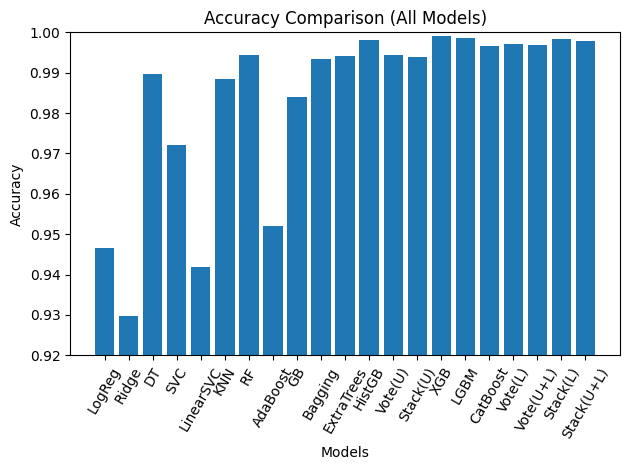

In [14]:
import matplotlib.pyplot as plt

# Model names (basic + ensemble)
model_names = [
    "LogReg", "Ridge", "DT", "SVC", "LinearSVC", "KNN",
    "RF", "AdaBoost", "GB", "Bagging", "ExtraTrees", "HistGB",
    "Vote(U)", "Stack(U)", "XGB", "LGBM", "CatBoost",
    "Vote(L)", "Vote(U+L)", "Stack(L)", "Stack(U+L)"
]

# Accuracy values (same order)
accuracies = [
    accuracy_score1, accuracy_score2, accuracy_score3,
    accuracy_score4, accuracy_score5, accuracy_score6,
    e_accuracy_score1, e_accuracy_score2, e_accuracy_score3,
    e_accuracy_score4, e_accuracy_score5, e_accuracy_score6,
    e_accuracy_score7, e_accuracy_score8, e_accuracy_score9,
    e_accuracy_score10, e_accuracy_score11, e_accuracy_score12,
    e_accuracy_score13, e_accuracy_score14, e_accuracy_score15
]

plt.figure()
plt.bar(model_names, accuracies)

plt.title("Accuracy Comparison (All Models)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.92, 1)   # 👈 y-axis range set

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# All predictions (tumhare variables)
all_models = {
    "LogReg": y1,
    "Ridge": y2,
    "DT": y3,
    "SVC": y4,
    "LinearSVC": y5,
    "KNN": y6,
    "RF": ey1,
    "AdaBoost": ey2,
    "GB": ey3,
    "Bagging": ey4,
    "ExtraTrees": ey5,
    "HistGB": ey6,
    "Vote(U)": ey7,
    "Stack(U)": ey8,
    "XGB": ey9,
    "LGBM": ey10,
    "CatBoost": ey11,
    "Vote(L)": ey12,
    "Vote(U+L)": ey13,
    "Stack(L)": ey14,
    "Stack(U+L)": ey15
}

# Metrics calculate
metrics = {}

for name, preds in all_models.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    metrics[name] = [acc, prec, rec, f1]

# 🔥 Top 5 models based on F1-score
top5 = dict(sorted(metrics.items(), key=lambda x: x[1][3], reverse=True)[:5])

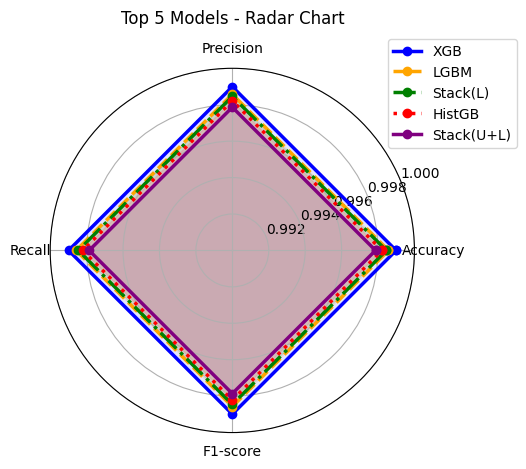

In [19]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Accuracy", "Precision", "Recall", "F1-score"]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))

plt.figure()
ax = plt.subplot(111, polar=True)

styles = ['-', '--', '-.', ':', '-']
colors = ['blue', 'orange', 'green', 'red', 'purple']

for (name, values), style, color in zip(top5.items(), styles, colors):
    values = values + [values[0]]

    ax.plot(
        angles, values,
        linestyle=style,
        marker='o',
        markersize=6,        # 👈 bigger markers
        linewidth=2.5,       # 👈 thicker lines
        color=color,
        label=name
    )
    ax.fill(angles, values, alpha=0.1, color=color)  # 👈 more visible fill

# axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# 🎯 zoom to 0.95–1
ax.set_ylim(0.99, 1.0)

plt.title("Top 5 Models - Radar Chart", y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

#ex2

In [20]:
all_models_acc = {
    # ===== Basic =====
    "LogReg": accuracy_score1,
    "Ridge": accuracy_score2,
    "DT": accuracy_score3,
    "SVC": accuracy_score4,
    "LinearSVC": accuracy_score5,
    "KNN": accuracy_score6,

    # ===== Ensemble (Bagging/Boosting) =====
    "RF": e_accuracy_score1,
    "AdaBoost": e_accuracy_score2,
    "GB": e_accuracy_score3,
    "Bagging": e_accuracy_score4,
    "ExtraTrees": e_accuracy_score5,
    "HistGB": e_accuracy_score6,
    "XGB": e_accuracy_score9,
    "LGBM": e_accuracy_score10,
    "CatBoost": e_accuracy_score11,

    # ===== Voting =====
    "Vote(U)": e_accuracy_score7,
    "Vote(L)": e_accuracy_score12,
    "Vote(U+L)": e_accuracy_score13,

    # ===== Stacking =====
    "Stack(U)": e_accuracy_score8,
    "Stack(L)": e_accuracy_score14,
    "Stack(U+L)": e_accuracy_score15
}



single_keys = [
    "LogReg","Ridge","DT","SVC","LinearSVC","KNN",
    "RF","AdaBoost","GB","ExtraTrees","HistGB",
    "XGB","LGBM","CatBoost"
]

best_single_acc = max([all_models_acc[k] for k in single_keys])
print("Best Single Model Accuracy:", best_single_acc)

Best Single Model Accuracy: 0.9989903789048581


In [21]:
import pandas as pd

rows = []

for name, acc in all_models_acc.items():

    # classify type
    if "Stack" in name:
        etype = "Stacking"
    elif "Vote" in name:
        etype = "Voting"
    elif name in ["RF", "Bagging", "ExtraTrees"]:
        etype = "Bagging"
    elif name in ["AdaBoost", "GB", "XGB", "LGBM", "CatBoost", "HistGB"]:
        etype = "Boosting"
    else:
        etype = "Basic"

    improvement = acc - best_single_acc

    rows.append([etype, name, acc, improvement])

df_arch = pd.DataFrame(rows, columns=[
    "Ensemble Type", "Model", "Accuracy", "Improvement vs Best Single"
])

# Sort by accuracy
df_arch = df_arch.sort_values(by="Accuracy", ascending=False)

print(df_arch)

   Ensemble Type       Model  Accuracy  Improvement vs Best Single
12      Boosting         XGB  0.998990                    0.000000
13      Boosting        LGBM  0.998575                   -0.000416
19      Stacking    Stack(L)  0.998456                   -0.000535
11      Boosting      HistGB  0.998218                   -0.000772
20      Stacking  Stack(U+L)  0.997862                   -0.001128
16        Voting     Vote(L)  0.997031                   -0.001960
17        Voting   Vote(U+L)  0.996912                   -0.002079
14      Boosting    CatBoost  0.996496                   -0.002494
15        Voting     Vote(U)  0.994358                   -0.004632
6        Bagging          RF  0.994358                   -0.004632
10       Bagging  ExtraTrees  0.994239                   -0.004751
18      Stacking    Stack(U)  0.993883                   -0.005107
9        Bagging     Bagging  0.993348                   -0.005642
2          Basic          DT  0.989666                   -0.00

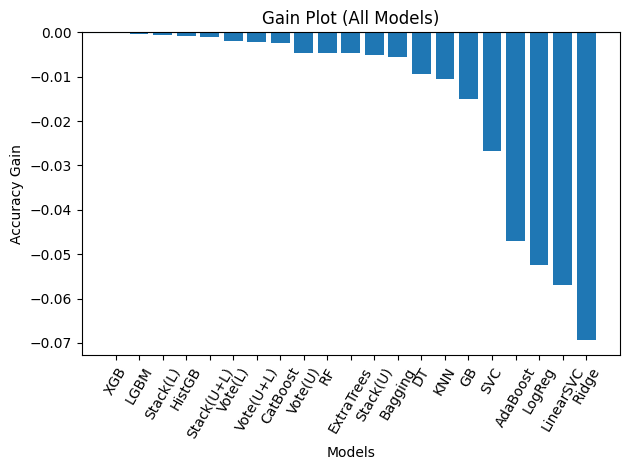

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_arch["Model"], df_arch["Improvement vs Best Single"])

plt.axhline(0)  # baseline

plt.title("Gain Plot (All Models)")
plt.xlabel("Models")
plt.ylabel("Accuracy Gain")

plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [23]:
best_model = df_arch.iloc[0]
print("\nBest Overall Model:\n", best_model)


Best Overall Model:
 Ensemble Type                 Boosting
Model                              XGB
Accuracy                       0.99899
Improvement vs Best Single         0.0
Name: 12, dtype: object


#ex3

In [25]:
data

,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,...,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,label
0,0,0.770650,-1.209804,-1.038798,-1.694301,-1.813126,1.633367,-1.552348,-1.062802,-1.743449,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
1,1,0.770650,-1.209804,-1.038798,-1.741891,-1.813126,1.731015,-1.677094,-1.062802,-1.825315,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
2,2,0.770650,-1.209804,-1.038798,-1.619269,-1.813126,1.482176,-1.366981,-1.062802,-1.616741,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
3,3,0.770650,-1.209804,-1.038798,-1.597784,-1.813126,1.439431,-1.316112,-1.062802,-1.580937,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
4,4,0.770650,-1.209804,-1.038798,-1.724538,-1.813126,1.695234,-1.630889,-1.062802,-1.795316,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84182,84182,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
84183,84183,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
84184,84184,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR
84185,84185,-1.854471,-0.984932,0.962651,-2.007632,3.508048,2.357622,-2.551555,-1.062802,-2.315164,...,-0.81683,-0.86773,-0.241381,-0.186165,-0.186165,-0.186165,-0.214164,-0.214164,-0.214164,nonTOR


In [26]:
import numpy as np

# Total samples
num_samples = data.shape[0]

# Target column
target_col = "label"

# Number of classes
num_classes = data[target_col].nunique()

# Class distribution
class_counts = data[target_col].value_counts()

print("Samples:", num_samples)
print("Classes:", num_classes)
print("Class Distribution:\n", class_counts)

Samples: 84187
Classes: 2
Class Distribution:
 label
nonTOR    69680
TOR       14507
Name: count, dtype: int64


In [27]:
from scipy.stats import entropy

# probabilities
probs = class_counts / num_samples

# entropy
dataset_entropy = entropy(probs, base=2)

print("Entropy:", dataset_entropy)

Entropy: 0.662981746234616


In [28]:
all_accuracies = list(all_models_acc.values())

best_acc = max(all_accuracies)
std_dev = np.std(all_accuracies)

print("Best Accuracy:", best_acc)
print("Std Dev:", std_dev)

Best Accuracy: 0.9989903789048581
Std Dev: 0.021111775652698023


In [29]:
df_table3 = pd.DataFrame([[
    "SMOTE Dataset",
    num_classes,
    num_samples,
    round(best_acc, 4),
    round(std_dev, 4),
    round(dataset_entropy, 4)
]], columns=[
    "Dataset", "Classes", "Samples", "Best Acc", "Std Dev", "Entropy"
])

print(df_table3)

         Dataset  Classes  Samples  Best Acc  Std Dev  Entropy
0  SMOTE Dataset        2    84187     0.999   0.0211    0.663


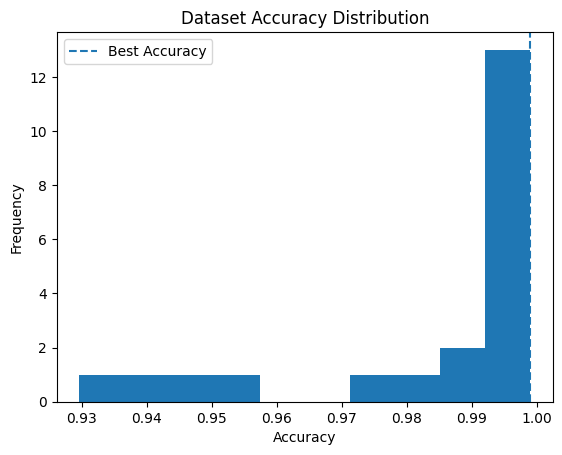

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.hist(all_accuracies, bins=10)

plt.title("Dataset Accuracy Distribution")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.axvline(best_acc, linestyle='--', label="Best Accuracy")

plt.legend()
plt.show()

#ex4

In [31]:
!pip install scikit-posthocs

In [35]:
from sklearn.model_selection import cross_val_score
import numpy as np

models = {
    "LogReg": m1,
    "Ridge": m2,
    "DT": m3,
    "SVC": m4,
    "LinearSVC": m5,
    "KNN": m6,
    "RF": em1,
    "AdaBoost": em2,
    "GB": em3,
    "Bagging": em4,
    "ExtraTrees": em5,
    "HistGB": em6,
    "XGB": em9,
    "LGBM": em10,
    "CatBoost": em11,
    "Vote(U)": em7,
    "Vote(L)": em12,
    "Vote(U+L)": em13,
    "Stack(U)": em8,
    "Stack(L)": em14,
    "Stack(U+L)": em15
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=3, scoring='accuracy')
    cv_results[name] = scores

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[LightGBM] [Info] Number of positive: 37163, number of negative: 7736
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6016
[LightGBM] [Info] Number of data points in the train set: 44899, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.827702 -> initscore=1.569429
[LightGBM] [Info] Start training from score 1.569429


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 37162, number of negative: 7737
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6025
[LightGBM] [Info] Number of data points in the train set: 44899, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.827680 -> initscore=1.569273
[LightGBM] [Info] Start training from score 1.569273


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 37163, number of negative: 7737
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008514 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6029
[LightGBM] [Info] Number of data points in the train set: 44900, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.827684 -> initscore=1.569300
[LightGBM] [Info] Start training from score 1.569300


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Learning rate set to 0.052292
0:	learn: 0.5811200	total: 18.2ms	remaining: 18.2s
1:	learn: 0.5022188	total: 30.7ms	remaining: 15.3s
2:	learn: 0.4353052	total: 48.8ms	remaining: 16.2s
3:	learn: 0.3761264	total: 66.5ms	remaining: 16.5s
4:	learn: 0.3272396	total: 80.3ms	remaining: 16s
5:	learn: 0.2961082	total: 94.3ms	remaining: 15.6s
6:	learn: 0.2663807	total: 107ms	remaining: 15.1s
7:	learn: 0.2450692	total: 118ms	remaining: 14.7s
8:	learn: 0.2254317	total: 133ms	remaining: 14.6s
9:	learn: 0.2092748	total: 150ms	remaining: 14.8s
10:	learn: 0.1968286	total: 163ms	remaining: 14.6s
11:	learn: 0.1878323	total: 179ms	remaining: 14.8s
12:	learn: 0.1804730	total: 216ms	remaining: 16.4s
13:	learn: 0.1655041	total: 229ms	remaining: 16.1s
14:	learn: 0.1591706	total: 241ms	remaining: 15.8s
15:	learn: 0.1473759	total: 254ms	remaining: 15.6s
16:	learn: 0.1416648	total: 266ms	remaining: 15.4s
17:	learn: 0.1366846	total: 279ms	remaining: 15.2s
18:	learn: 0.1333653	total: 291ms	remaining: 15s
19:	learn

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [36]:
cv_results

{'LogReg': array([0.94383073, 0.94383073, 0.94797096]),
 'Ridge': array([0.93109131, 0.92917595, 0.93144461]),
 'DT': array([0.98708241, 0.98917595, 0.98988819]),
 'SVC': array([0.96788419, 0.96654788, 0.97042185]),
 'LinearSVC': array([0.94093541, 0.94187082, 0.94449641]),
 'KNN': array([0.9844098 , 0.98592428, 0.98530001]),
 'RF': array([0.99314031, 0.99345212, 0.99425364]),
 'AdaBoost': array([0.94712695, 0.95153675, 0.94984186]),
 'GB': array([0.98427617, 0.9854343 , 0.98579001]),
 'Bagging': array([0.99314031, 0.99238307, 0.99349637]),
 'ExtraTrees': array([0.99291759, 0.99349666, 0.99363001]),
 'HistGB': array([0.99741648, 0.99826281, 0.99830727]),
 'XGB': array([0.99804009, 0.99844098, 0.99884182]),
 'LGBM': array([0.99804009, 0.99884187, 0.99861909]),
 'CatBoost': array([0.99643653, 0.99710468, 0.99657   ]),
 'Vote(U)': array([0.9925167 , 0.99331849, 0.99438728]),
 'Vote(L)': array([0.99599109, 0.99683742, 0.99683728]),
 'Vote(U+L)': array([0.99585746, 0.9963029 , 0.99648091]),

In [37]:
from scipy.stats import friedmanchisquare

scores_list = list(cv_results.values())

stat, p = friedmanchisquare(*scores_list)

print("Friedman Test p-value:", p)

mean_scores = {k: np.mean(v) for k, v in cv_results.items()}
best_model_name = max(mean_scores, key=mean_scores.get)

print("Best Model:", best_model_name)

Friedman Test p-value: 8.862890266935022e-06
Best Model: LGBM


In [38]:
from scipy.stats import wilcoxon

results = []

best_scores = cv_results[best_model_name]

for name, scores in cv_results.items():
    if name == best_model_name:
        continue

    stat, p_val = wilcoxon(best_scores, scores)

    significant = "Yes" if p_val < 0.05 else "No"

    results.append([name, p_val, significant])

In [39]:
import pandas as pd

df_stats = pd.DataFrame(results, columns=[
    "Model", "p-value vs Best", "Significant?"
])

print(df_stats)

         Model  p-value vs Best Significant?
0       LogReg             0.25           No
1        Ridge             0.25           No
2           DT             0.25           No
3          SVC             0.25           No
4    LinearSVC             0.25           No
5          KNN             0.25           No
6           RF             0.25           No
7     AdaBoost             0.25           No
8           GB             0.25           No
9      Bagging             0.25           No
10  ExtraTrees             0.25           No
11      HistGB             0.25           No
12         XGB             1.00           No
13    CatBoost             0.25           No
14     Vote(U)             0.25           No
15     Vote(L)             0.25           No
16   Vote(U+L)             0.25           No
17    Stack(U)             0.25           No
18    Stack(L)             0.25           No
19  Stack(U+L)             0.25           No


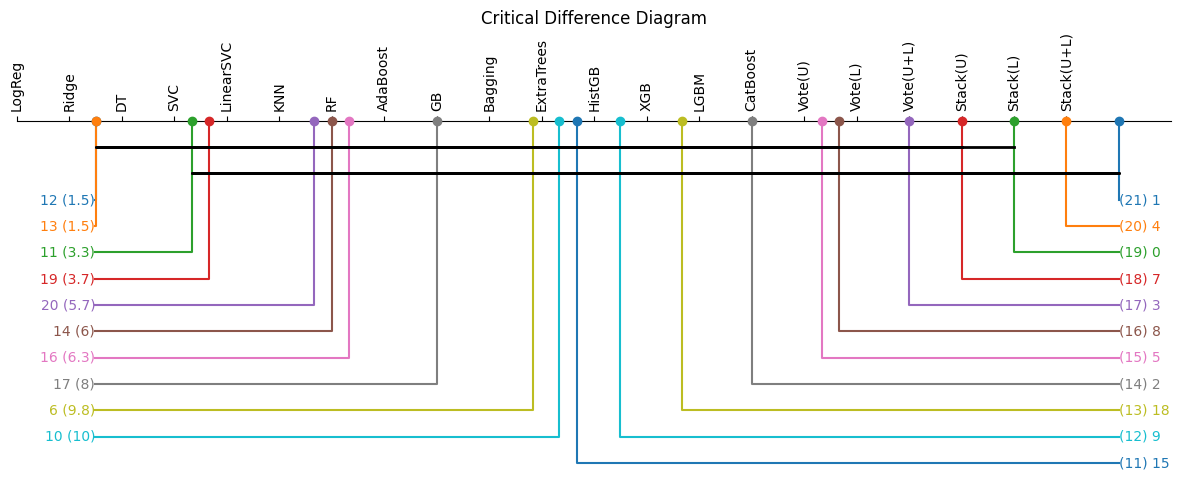

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import rankdata

# =========================
# Step 1: Prepare data
# =========================
model_names = list(cv_results.keys())

# shape: (models, folds) → (folds, models)
data = np.array(list(cv_results.values())).T

# =========================
# Step 2: Nemenyi test
# =========================
nemenyi = sp.posthoc_nemenyi_friedman(data)

# ⚠️ IMPORTANT: keep as DataFrame (NO .values)

# =========================
# Step 3: Rank calculation
# =========================
ranks = np.array([rankdata(-row) for row in data])  # higher acc = better
mean_ranks = ranks.mean(axis=0)

# =========================
# Step 4: Plot CD Diagram
# =========================
plt.figure(figsize=(12, 5))

sp.critical_difference_diagram(mean_ranks, nemenyi)

# ❗ manual labels (old version fix)
plt.xticks(range(len(model_names)), model_names, rotation=90)

plt.title("Critical Difference Diagram")
plt.tight_layout()
plt.show()

#download models

In [ ]:
import shutil
from google.colab import files

# Name of the folder to download
folder_name = 'saved_models'
zip_name = 'saved_models.zip'

# Compress the folder
shutil.make_archive('saved_models', 'zip', folder_name)

# Download the file
files.download(zip_name)

print(f'✅ {zip_name} is being prepared for download.')